In [56]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 1. Faster Loading
with open("Hill.slicesWOT.plt", 'r') as f:
    # Filter data lines and replace Fortran 'D' with 'E'
    clean_lines = [l.replace('D', 'E') for l in f if l.strip() and l.strip()[0] in '0123456789-.']

# Convert to a single numpy array (Shape: 33800, 6)
raw_data = np.loadtxt(clean_lines)

# 2. Reshape into (Blocks, X_steps, Y_steps, Variables)
# I=65, J=65 means 4225 points per block. 33800/4225 = 8 blocks.
nx, ny = 65, 65
n_blocks = raw_data.shape[0] // (nx * ny)
data_4d = raw_data.reshape((n_blocks, nx, ny, 6))

In [523]:
def plot_full_wind_field(data_4d, block_type=0, depth=1):


    # 1. Concatenate all 8 blocks along the streamwise (x) axis
    # data_4d shape is (8, 65, 65, 6) -> [Block, X_idx, Y_idx, Var]
    # We concatenate along axis 1 to join them side-by-side
    full_x = np.concatenate([data_4d[i+block_type, :, :, 0] for i in range(0, 8*3,3)], axis=0)
    full_y = np.concatenate([data_4d[i+block_type, :, :, 1] for i in range(0, 8*3,3)], axis=0)
    full_u = np.concatenate([data_4d[i+block_type, :, :, 2] for i in range(0, 8*3,3)], axis=0)

    plt.figure(figsize=(16, 6))

    # 2. Use pcolormesh with the combined global coordinates
    # This automatically handles the Gaussian "warping" across the whole domain
    mesh = plt.pcolormesh(full_x, full_y, full_u, shading='gouraud', cmap='Blues', vmin=np.min(full_u)*depth, vmax=np.max(full_u)*depth)
    
    # 3. Fill the Gaussian Hill (the ground)
    # X[:, 0] and Y[:, 0] represent the surface coordinates across the full domain
    plt.fill_between(full_x[:, 0], full_y.min() - 1, full_y[:, 0], color='tab:green', alpha=0.6)

    # 4. Formatting
    plt.colorbar(mesh, label='u-velocity [m/s]', orientation='vertical', pad=0.15)
    plt.title("Full RANS Wind Field over Gaussian Hill (All Blocks)")
    plt.xlabel("Streamwise Distance (x)")
    plt.ylabel("Vertical Height (y)")
    
    # Adjust limits to focus on the flow
    plt.ylim(full_y.min(), full_y.max()*1.1)
    
    plt.xlim(-5,5)
    plt.tight_layout()
    plt.show()

    return full_x, full_y, full_u

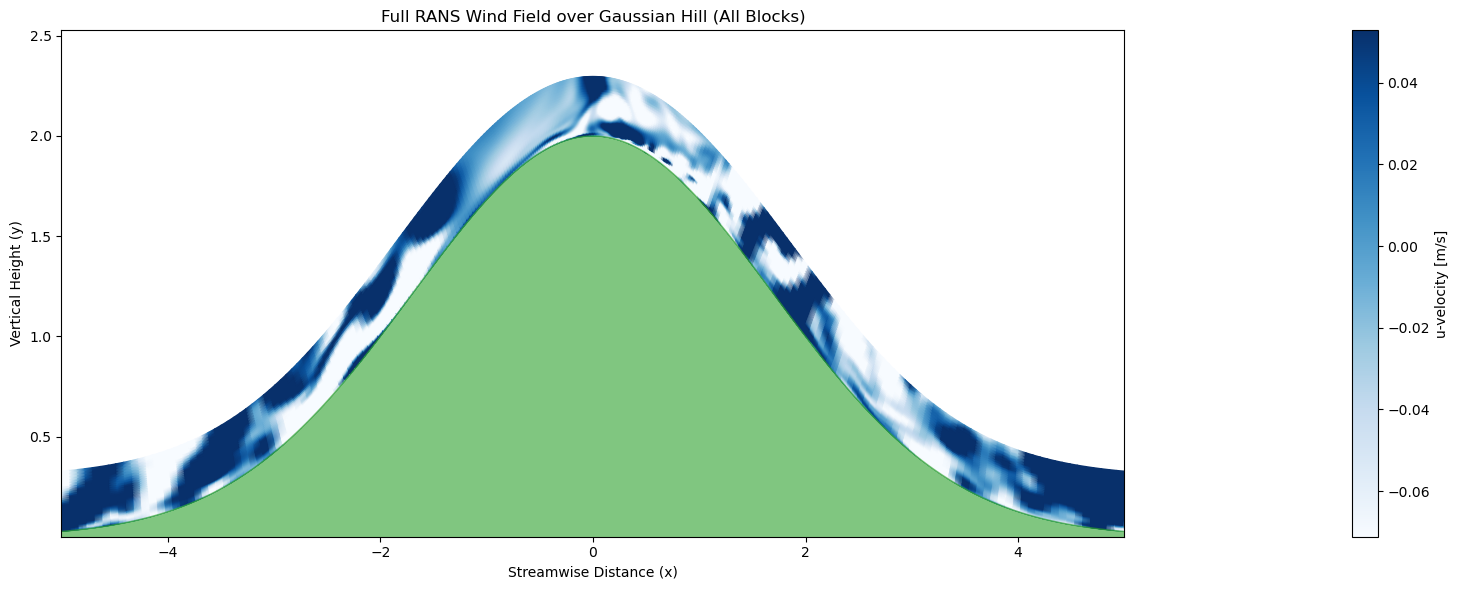

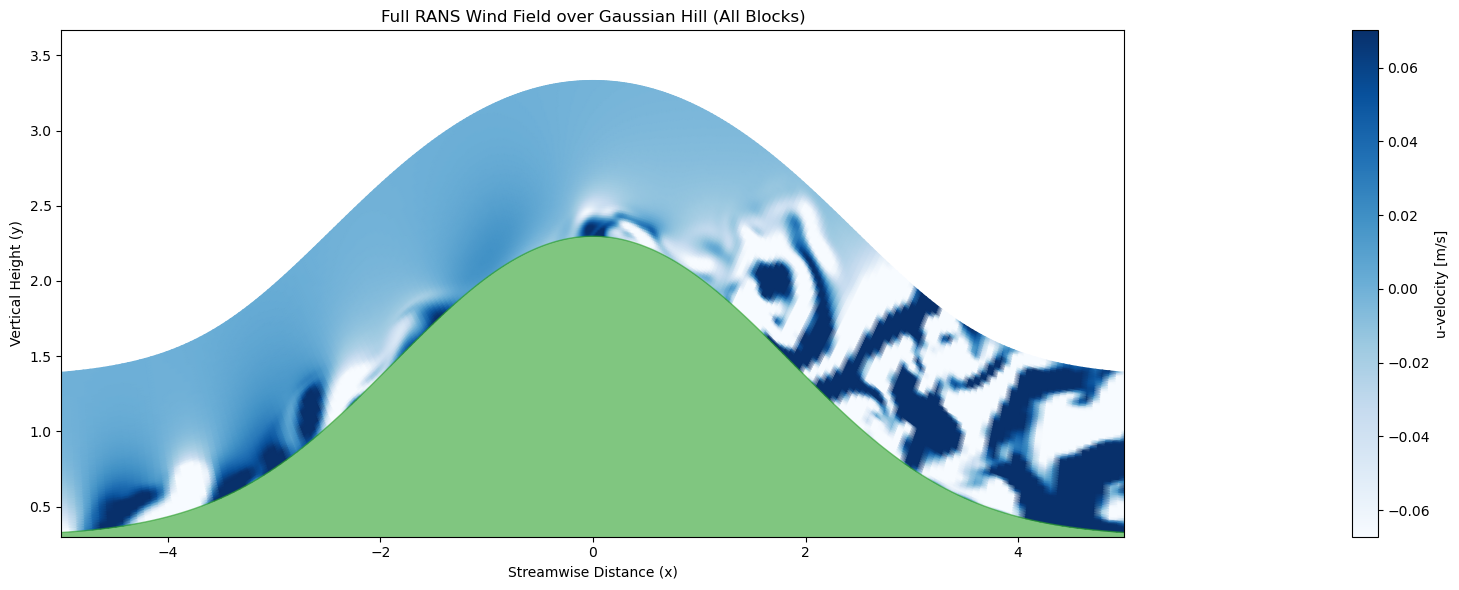

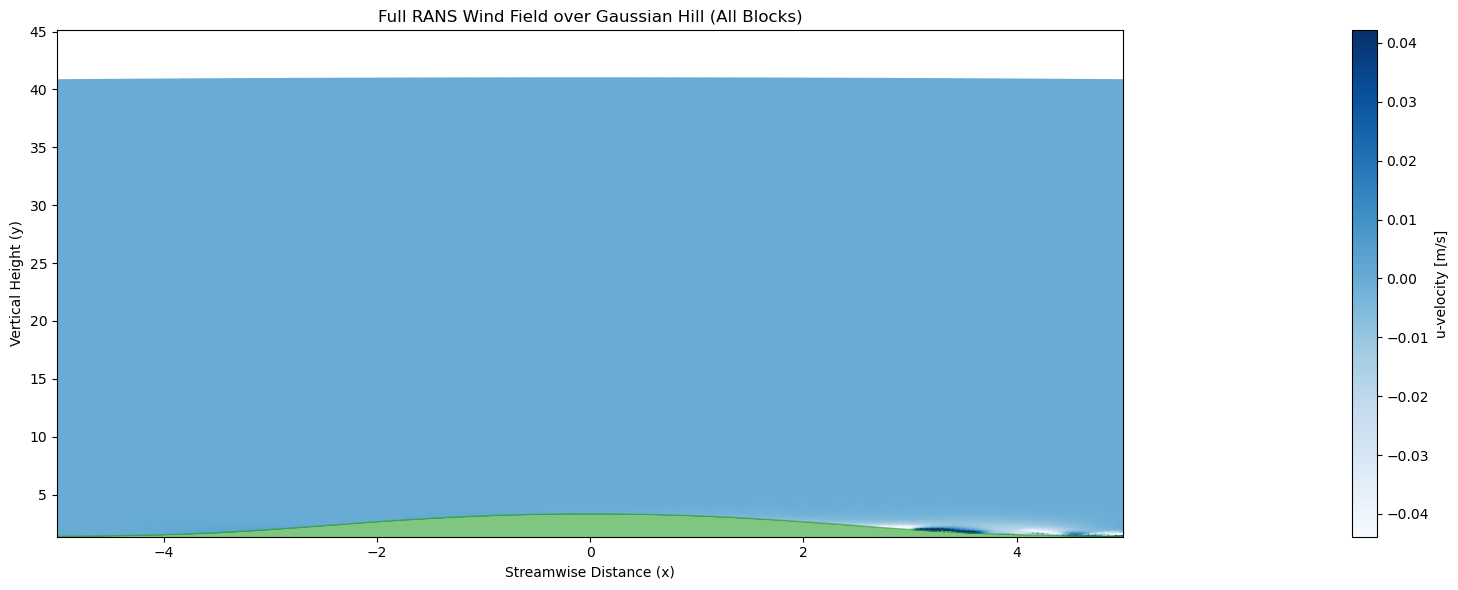

In [522]:

# Run the unified plot
plot_full_wind_field(data_4d, 0)
x, y, u = plot_full_wind_field(data_4d, 1)
_ = plot_full_wind_field(data_4d, 2) # useless

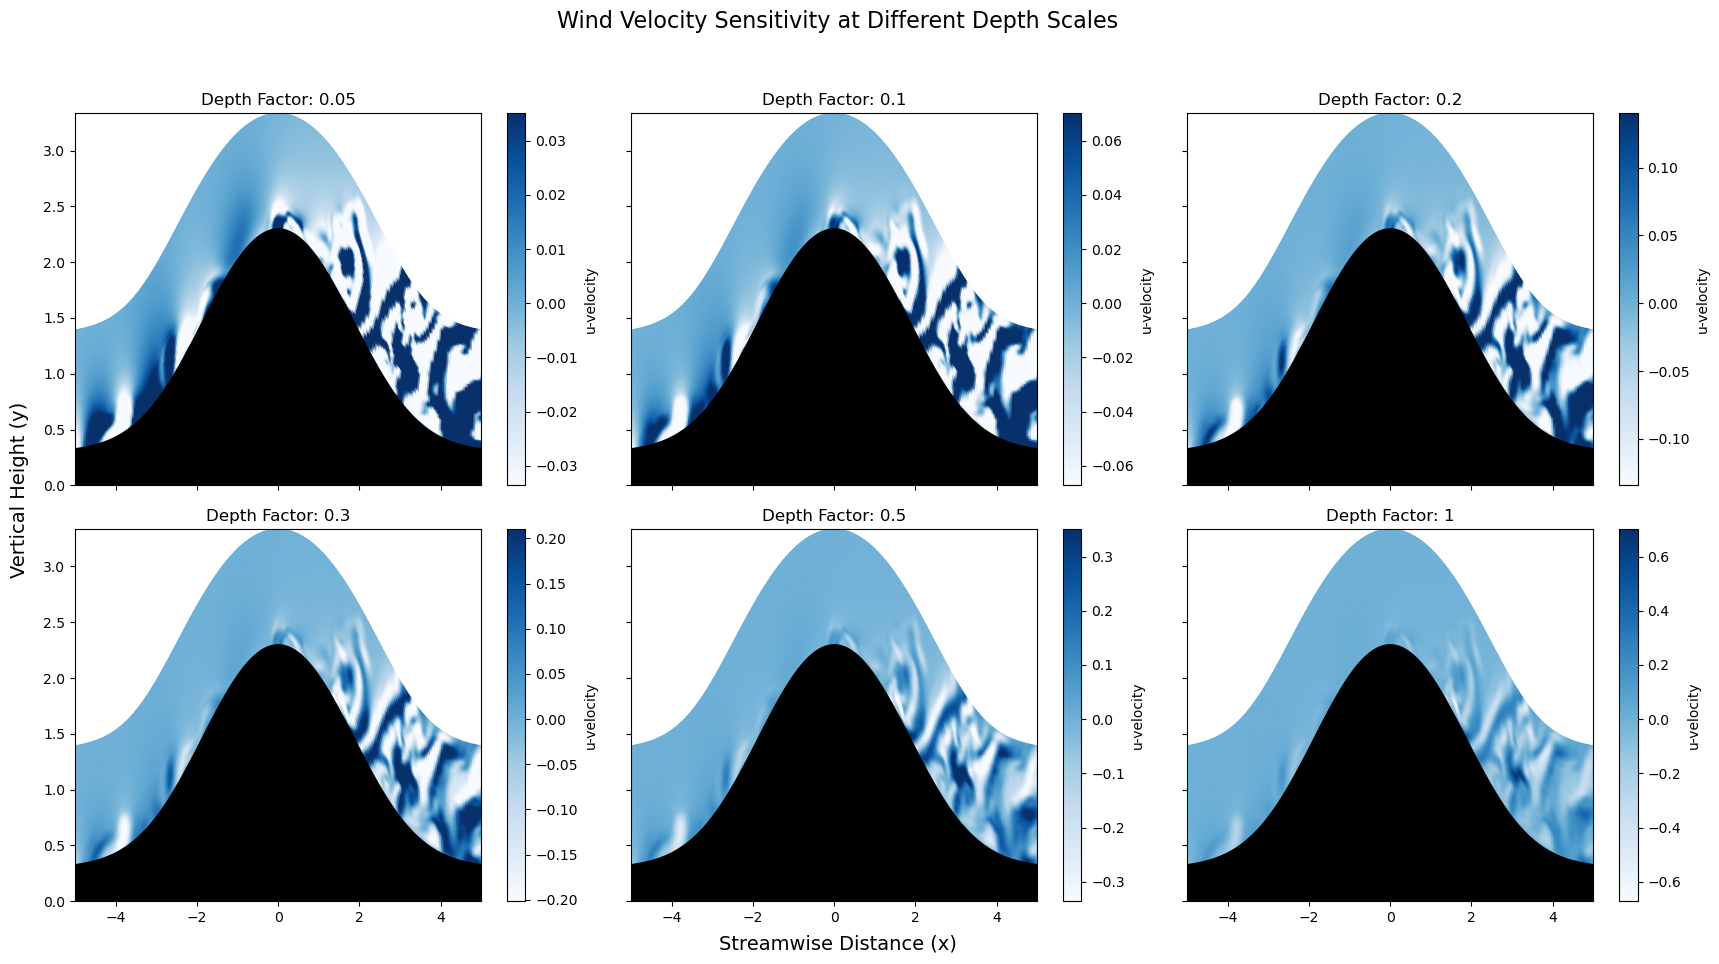

In [531]:
import numpy as np
import matplotlib.pyplot as plt

depths = [0.05, 0.1, 0.2, 0.3, 0.5, 1]

# 1. Create a figure with 2 rows and 3 columns
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)

# Flatten the axes array to easily iterate through it (from 2D to 1D)
axes_flat = axes.flatten()

for i, depth in enumerate(depths):
    ax = axes_flat[i]
    
    # 2. Plot the Heatmesh
    # We apply your vmin/vmax scaling logic here
    im = ax.pcolormesh(x,y,u, 
                       shading='gouraud', 
                       cmap='Blues', 
                       vmin=np.min(u)*depth, 
                       vmax=np.max(u)*depth)
    
    # 3. Add the Gaussian Hill fill (Solid ground)
    # Using the first column of x and y as the surface profile
    ax.fill_between(x[:, 0], y.min() - 0.5, y[:, 0], color='black')
    
    # 4. Formatting each subplot
    ax.set_title(f"Depth Factor: {depth}")
    ax.set_xlim(-5, 5)
    ax.set_ylim(0, y.max())
    
    # Add a colorbar for each individual scale
    plt.colorbar(im, ax=ax, label='u-velocity')

# Add global labels
fig.text(0.5, 0.04, 'Streamwise Distance (x)', ha='center', fontsize=14)
fig.text(0.04, 0.5, 'Vertical Height (y)', va='center', rotation='vertical', fontsize=14)

plt.suptitle("Wind Velocity Sensitivity at Different Depth Scales", fontsize=16)
plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.show()